In [1]:
from sqlalchemy import create_engine, MetaData, Table, select, insert
from sqlalchemy.exc import SQLAlchemyError
from dotenv import load_dotenv
load_dotenv()
import os
from tqdm import tqdm
import pandas as pd
import regex as re

import spacy



from nltk.metrics import distance
import scipy.spatial as spatial
import numpy as np
from scipy.cluster.vq import kmeans


In [2]:
nlp = spacy.load("en_core_web_trf")

/Users/tom/Fine-arts-ML/Fine-Arts-Main/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def create_db_connection():
    DB_HOST = os.getenv("DB_HOST")
    DB_NAME = os.getenv("DB_NAME")
    DB_USER = os.getenv("DB_USER")
    DB_PASSWORD = os.getenv("DB_PASSWORD")
    engine = create_engine('postgresql+pg8000://'+DB_USER+':'+DB_PASSWORD+'@'+DB_HOST+':5432/'+DB_NAME)
    return engine


def get_tags():
    try:
        engine = create_db_connection()
        df_systag = pd.read_sql_table('oc_systemtag', engine)
        df_tagmap = pd.read_sql_table('oc_systemtag_object_mapping', engine)

    except SQLAlchemyError as e:
        print(f"An error occurred: {e}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
    return df_systag, df_tagmap

In [4]:
df_systag, df_tagmap = get_tags()

In [5]:
df_dense = df_systag[:400]
df_systag = df_systag[:400]
df_systag2= df_systag


In [6]:
def lemmatize_list(list):
    lemma_list = []
    for word in list:
        doc = nlp(word)
        lemma_list.append(" ".join([token.lemma_ for token in doc]))
    return lemma_list

df_dense['name'] = df_dense['name'].str.lower()
df_dense["split_n"] = df_dense.name.apply(lambda x: re.sub('[^A-Za-z0-9]+', ' ', x))
df_dense["split_n"] = df_dense.split_n.str.split()
df_dense["split_n_lem"] = df_dense.split_n.apply(lemmatize_list)
df_dense = df_dense.explode('split_n_lem')
#df_dense = df_dense.groupby('split_n_lem')['id'].agg(list).reset_index()
#df_dense['lowest_id'] = df_dense['id'].apply(min)

In [7]:
df_lem = df_dense[['id','split_n_lem']].copy()
df_lem = df_lem.groupby('id')['split_n_lem'].agg(' '.join)
df_lem = df_lem.reset_index()


In [8]:
df_dense2 = df_dense.merge(df_lem, on='id', how='left')
df_dense2['name'] = df_dense2['split_n_lem_y']
df_dense2 = df_dense2.drop(columns=['split_n_lem_x','split_n','split_n_lem_y'])
df_dense2 = df_dense2.drop_duplicates("id")

df_dense2 gives back a lemmatized version of the original table.

In [9]:
df_dense2[:10]

,id,name,visibility,editable,etag,color
0,116,art style,1,1,None,None
2,117,flower,1,1,None,None
3,118,nature,1,1,None,None
4,119,still life,1,1,None,None
6,120,vase,1,1,None,None
7,121,red,1,1,None,None
8,122,white,1,1,None,None
9,123,orange,1,1,None,None
10,124,green,1,1,None,None
11,125,bloom,1,1,None,None


In [ ]:
df_lem = df_dense[['id','split_n_lem']].copy()
df_lem

,id,split_n_lem
0,116,art style
1,117,flower
2,118,nature
3,119,still life
4,120,vase
...,...,...
395,511,graphic art
396,512,colorful fish
397,513,pattern fish
398,514,fish


In [ ]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sentence_transformers import SentenceTransformer, util
model = SentenceTransformer("all-MiniLM-L6-v2")

/Users/tom/Fine-arts-ML/Fine-Arts-Main/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
def choose_classifier(X):
    X1 = X / (X**2).sum(axis=-1, keepdims=True)
    vv = []
    cc = np.arange(2, len(X))
    for nclusters in cc:
        km_model = KMeans(nclusters).fit(X1)
        labels = km_model.labels_
        v = silhouette_score(X1, labels)
        vv.append(v)
    nclusters = cc[np.argmax(vv)]
    return KMeans(nclusters).fit(X1)

In [ ]:
embeddings = model.encode(result2.lemma, show_progress_bar=True, convert_to_numpy=True)

#classifier = choose_classifier(embeddings)


Batches: 100%|██████████| 46/46 [00:00<00:00, 95.85it/s] 


In [ ]:
for i, (v, s) in enumerate(zip(embeddings, result2.lemma)):
    print(classifier.predict(v[np.newaxis]), s)

In [ ]:
from kmeans_pytorch import kmeans
import torch
def detect_clusters(X, nclusters, tol=1e-6):
  X = torch.as_tensor(X)
  assert X.ndim == 2
  # Project the points in a hypersphere
  X1 = X / torch.sqrt(torch.sum(X**2, axis=-1, keepdims=True))

  # Run kmeans on the normalized points with euclidean distance
  cluster_ID, C = kmeans(X1, nclusters, distance='euclidean', tol=tol)
  return cluster_ID, C

running k-means on cpu..


[running kmeans]: 21it [00:00, 231.59it/s, center_shift=0.000000, iteration=21, tol=0.000001]


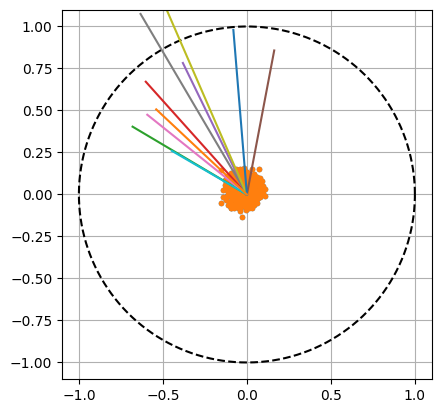

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch;
#### THE RESUTLS ####
cluster_ID, C = detect_clusters(embeddings, 10)
# Avoid distortion of the angles
plt.axes().set_aspect('equal')
# Initial points
plt.plot(embeddings[:,0], embeddings[:,1], '.')
# Reference circle
theta = torch.linspace(0, 2*np.pi, 1000)
plt.plot(torch.cos(theta), torch.sin(theta), '--k')
plt.plot(embeddings[:,0],embeddings[:,1], '.')
xlim = plt.xlim()
ylim = plt.ylim()
plt.xlim(xlim)
plt.ylim(ylim)

# Draw lines in the directions given by the centroids
R = 20
for c in C:
    plt.plot([0, c[0]*R], [0, c[1]*R]);

plt.grid();

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
# Generate embeddings
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(result2.lemma, show_progress_bar=True, convert_to_numpy=True)

# Cluster using K-Means
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(embeddings)

# Print clusters
for tag, cluster in zip(result2.lemma, clusters):
    print(f"{tag}: Cluster {cluster}")